# Results Tables
Generates Table 1, Table 2, Table 3 for Milestone 2.

In [ ]:
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd
from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import rdMolDescriptors
RDLogger.DisableLog("rdApp.*")

ROOT = Path(".").resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

GEN_DIR = ROOT / "data" / "generation_stratified"

METHODS = {
    "Baseline": GEN_DIR / "baseline"  / "baseline_scores.csv",
    "CReM":     GEN_DIR / "crem"      / "crem_scores.csv",
    "mmpdb":    GEN_DIR / "mmpdb"     / "mmpdb_scores.csv",
    "JT-VAE":   GEN_DIR / "jtvae"     / "jtvae_scores.csv",
    "LibINVENT":GEN_DIR / "libinvent" / "libinvent_scores.csv",
}

# Global per-depth checkpoints (produced by synthesizability_scoring.ipynb)
DEPTH_CKPTS = {
    1: GEN_DIR / "synth_depth1.json",
    3: GEN_DIR / "synth_depth3.json",
    6: GEN_DIR / "synth_depth6.json",
}

# Primary depth used for Tables 1 & 2 and all visualizations.
# is_synth_depthN = passed property gate (TAU_T=0, TAU_D=0.5) AND synthesizable.
PRIMARY_DEPTH = 6
PRIMARY_COL   = f"is_synth_depth{PRIMARY_DEPTH}"

METHOD_LABELS = {
    "Baseline":  "Baseline (Luo et al., 2025)",
    "CReM":      "CReM (Polishchuk, 2020)",
    "mmpdb":     "mmpdb (Dalke et al., 2018)",
    "JT-VAE":    "JT-VAE (Jin et al., 2019)",
    "LibINVENT": "LibINVENT (Fialkova et al., 2022)",
}

BIN_ORDER = ["<0.5", "0.5-0.7", "0.7-0.85", "0.85-1.0"]


In [ ]:
# Load CSVs -- is_synth_depthN columns are written by synthesizability_scoring.ipynb
dfs = {}
for name, path in METHODS.items():
    df = pd.read_csv(path)
    # Ensure primary depth column exists (fallback to legacy is_synth if needed)
    if PRIMARY_COL not in df.columns:
        if "is_synth" in df.columns:
            df[PRIMARY_COL] = df["is_synth"]
            print(f"{name}: WARNING -- {PRIMARY_COL} missing, using legacy is_synth")
        else:
            df[PRIMARY_COL] = False
            print(f"{name}: WARNING -- no synth column found, defaulting to False")
    df["method_key"] = name
    dfs[name] = df
    depth_cols = [c for c in df.columns if c.startswith("is_synth_depth")]
    parts = " | ".join(f"{c}={df[c].sum()}" for c in sorted(depth_cols))
    print(f"{name:<12}: {len(df):>6,} variants | {parts}")

all_df = pd.concat(dfs.values(), ignore_index=True)


In [ ]:
# Diversity helper
def ecfp4(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return None
    return rdMolDescriptors.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)

def hit_diversity(smiles_list):
    fps = [ecfp4(s) for s in smiles_list]
    fps = [f for f in fps if f is not None]
    if len(fps) < 2: return np.nan
    sims = [DataStructs.TanimotoSimilarity(fps[i], fps[j])
            for i in range(len(fps)) for j in range(i+1, len(fps))]
    return round(1.0 - float(np.mean(sims)), 4)

---
## Table 1: Overall Comparative Performance Metrics

In [ ]:
baseline_hits = set(dfs['Baseline'].loc[dfs['Baseline'][PRIMARY_COL], 'variant_smiles'])

rows = []
for name in METHODS:
    df = dfs[name]
    hits = df[df[PRIMARY_COL]]
    hit_smi = list(hits['variant_smiles'].unique())
    n_total = len(df)
    n_hits  = len(hit_smi)

    hit_rate  = round(100 * n_hits / n_total, 2) if n_total > 0 else 0
    exp_factor = round(n_hits / len(baseline_hits), 3) if name != 'Baseline' and len(baseline_hits) > 0 else 1.0
    sub_cons  = round(hits['tanimoto'].median(), 3)    if n_hits > 0 else np.nan
    phys_cons = round(hits['desirability'].median(), 3) if n_hits > 0 else np.nan
    qed_med   = round(hits['qed'].median(), 3)          if n_hits > 0 else np.nan
    diversity = hit_diversity(hit_smi)

    rows.append({
        'Method':                    METHOD_LABELS[name],
        'Hit Rate (%)':              hit_rate,
        'Expansion Factor':          exp_factor,
        'Substructural Cons.':       sub_cons,
        'Physicochemical Cons.':     phys_cons,
        'Drug-likeness (QED)':       qed_med,
        'Chemical Diversity':        diversity,
    })

table1 = pd.DataFrame(rows)
print(f'(depth {PRIMARY_DEPTH})\n')
print(table1.to_string(index=False))

---
## Table 2: Expansion Factor Stratified by Baseline Quality

In [ ]:
# Baseline hit rate per bin
baseline_df = dfs['Baseline']
baseline_bin_hits = {
    b: set(baseline_df[(baseline_df['quality_bin'] == b) & baseline_df[PRIMARY_COL]]['variant_smiles'])
    for b in BIN_ORDER
}
baseline_bin_total = {
    b: len(baseline_df[baseline_df['quality_bin'] == b])
    for b in BIN_ORDER
}

rows2 = []
for b in BIN_ORDER:
    n_base_hits  = len(baseline_bin_hits[b])
    n_base_total = baseline_bin_total[b]
    base_hit_rate = round(100 * n_base_hits / n_base_total, 2) if n_base_total > 0 else 0

    row = {'Baseline Quality': b.replace('<0.5','Low (<0.5)'
               ).replace('0.5-0.7','Med-Low (0.5-0.7)'
               ).replace('0.7-0.85','Med-High (0.7-0.85)'
               ).replace('0.85-1.0','High (0.85-1.0)'),
           'Baseline Hit Rate (%)': base_hit_rate}

    for name in ['CReM', 'mmpdb', 'JT-VAE', 'LibINVENT']:
        df = dfs[name]
        method_hits = set(df[(df['quality_bin'] == b) & df[PRIMARY_COL]]['variant_smiles'])
        ef = round(len(method_hits) / n_base_hits, 3) if n_base_hits > 0 else float('inf')
        row[f'{name} Expansion'] = ef

    rows2.append(row)

table2 = pd.DataFrame(rows2)
print(f'(depth {PRIMARY_DEPTH})\n')
print(table2.to_string(index=False))

---
## Table 3: Synthesizability Sensitivity Analysis
> **Note:** Current data has only one AiZynthFinder depth. Depth 1 / Depth 6 rows require re-running `synthesizability_scoring.ipynb` with `max_depth` set to 1 and 6.

In [ ]:
# Read hit rates per depth directly from is_synth_depthN columns in the loaded CSVs.
# Depths whose column is absent (run not yet completed) are reported as '--'.

def hit_rate_depth(name, depth):
    col = f'is_synth_depth{depth}'
    df = dfs[name]
    if col not in df.columns:
        return np.nan
    return round(100 * df[col].sum() / len(df), 2)

rows3 = []
for name in METHODS:
    hr1 = hit_rate_depth(name, 1)
    hr3 = hit_rate_depth(name, 3)
    hr6 = hit_rate_depth(name, 6)
    abs_chg = round(hr3 - hr1, 2) if not (np.isnan(hr1) or np.isnan(hr3)) else np.nan
    rel_chg = round(abs_chg / hr1, 3) if not np.isnan(abs_chg) and hr1 > 0 else np.nan
    rows3.append({
        'Method':                   METHOD_LABELS[name],
        'Depth 1 Hit Rate (%)':     hr1,
        'Depth 3 Hit Rate (%)':     hr3,
        'Depth 6 Hit Rate (%)':     hr6,
        'Absolute Change (1→3)':    abs_chg,
        'Relative Change (1→3)':    rel_chg,
    })

table3 = pd.DataFrame(rows3)
print(table3.to_string(index=False))

---
## LaTeX Output

In [ ]:
def fmt(v):
    if isinstance(v, float) and np.isnan(v): return '--'
    if isinstance(v, float): return f'{v:.3f}'
    return str(v)

def df_to_latex(df, label, caption):
    cols = list(df.columns)
    col_fmt = 'l' + 'c' * (len(cols) - 1)
    header = ' & '.join(f'\\textbf{{{c}}}' for c in cols) + ' \\\\'
    lines = [
        r'\begin{table}[ht]',
        r'\centering',
        f'\\caption{{{caption}}}',
        f'\\label{{{label}}}',
        f'\\begin{{tabular}}{{{col_fmt}}}',
        r'\toprule',
        header,
        r'\midrule',
    ]
    for _, row in df.iterrows():
        lines.append(' & '.join(fmt(v) for v in row) + ' \\\\')
    lines += [r'\bottomrule', r'\end{tabular}', r'\end{table}']
    return '\n'.join(lines)

print('=== TABLE 1 ===\n')
print(df_to_latex(table1, 'tab:overall',
    'Overall comparative performance metrics across all modification methods.'))

print('\n=== TABLE 2 ===\n')
print(df_to_latex(table2, 'tab:expansion-stratified',
    'Expansion factor stratified by baseline synthesizability quality.'))

print('\n=== TABLE 3 ===\n')
print(df_to_latex(table3, 'tab:sensitivity',
    'Synthesizability sensitivity analysis across AiZynthFinder search depths.'))

---
## Visualizations

Figures for Milestone 2. All figures load `is_synth` directly from the scored CSVs (written by `synthesizability_scoring.ipynb`).

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Load data from CSVs (is_synth_depthN columns written by synthesizability_scoring) ──
VIZ_METHODS = ['Baseline', 'CReM', 'mmpdb', 'JT-VAE', 'LibINVENT']
CSV_MAP = {
    'Baseline':  GEN_DIR / 'baseline'  / 'baseline_scores.csv',
    'CReM':      GEN_DIR / 'crem'      / 'crem_scores.csv',
    'mmpdb':     GEN_DIR / 'mmpdb'     / 'mmpdb_scores.csv',
    'JT-VAE':    GEN_DIR / 'jtvae'     / 'jtvae_scores.csv',
    'LibINVENT': GEN_DIR / 'libinvent' / 'libinvent_scores.csv',
}

viz_dfs = {name: pd.read_csv(path) for name, path in CSV_MAP.items()}

# Use primary depth column for all visualizations
VIZ_DEPTH = PRIMARY_DEPTH
VIZ_COL   = f'is_synth_depth{VIZ_DEPTH}'

# Property gate: matches synthesizability_scoring.ipynb defaults
TAU_T_VIZ = 0.0
TAU_D_VIZ = 0.5

for name, df in viz_dfs.items():
    gate = (df['tanimoto'] >= TAU_T_VIZ) & (df['desirability'] >= TAU_D_VIZ)
    synth_col = VIZ_COL if VIZ_COL in df.columns else 'is_synth'
    print(f'{name:<12}: {len(df):>6,} total | {gate.sum():>5} pass gate | {df[synth_col].sum():>4} synth (depth {VIZ_DEPTH})')

PALETTE = {
    'Baseline':  '#4c72b0',
    'CReM':      '#55a868',
    'mmpdb':     '#c44e52',
    'JT-VAE':    '#dd8452',
    'LibINVENT': '#8172b3',
}
COLORS = [PALETTE[m] for m in VIZ_METHODS]

plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

### Figure 1: Molecule Funnel — Variants → Property Gate → Synthesizable

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))

x = np.arange(len(VIZ_METHODS))
w = 0.26

totals    = [len(viz_dfs[m]) for m in VIZ_METHODS]
gate_pass = [
    int(((viz_dfs[m]["tanimoto"] >= TAU_T_VIZ) & (viz_dfs[m]["desirability"] >= TAU_D_VIZ)).sum())
    for m in VIZ_METHODS
]
# Synthesizable = is_synth_depthN AND property gate (ensures synth is always a subset of gate_pass).
# Without the gate intersection, the same SMILES scored True via one seed can appear in rows
# that fail the property gate when paired with a different seed, inflating the count.
synth = [
    int((
        viz_dfs[m][VIZ_COL] &
        (viz_dfs[m]["tanimoto"] >= TAU_T_VIZ) &
        (viz_dfs[m]["desirability"] >= TAU_D_VIZ)
    ).sum()) if VIZ_COL in viz_dfs[m].columns else 0
    for m in VIZ_METHODS
]

b1 = ax.bar(x - w, totals,    width=w, label="Total variants",                    color="#aec6e8", edgecolor="white")
b2 = ax.bar(x,     gate_pass, width=w, label="Pass property gate",                 color="#ffcc80", edgecolor="white")
b3 = ax.bar(x + w, synth,     width=w, label=f"Synthesizable (depth {VIZ_DEPTH})", color="#80cbc4", edgecolor="white")

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 200, f"{h:,}",
                ha="center", va="bottom", fontsize=7, rotation=90)

ax.set_xticks(x)
ax.set_xticklabels(VIZ_METHODS)
ax.set_ylabel("Molecule count")
ax.set_title("Figure 1: Molecule Funnel by Method", fontweight="bold")
ax.legend(frameon=False)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
plt.tight_layout()
plt.savefig(GEN_DIR / "fig1_funnel.png", bbox_inches="tight")
plt.show()


### Figure 2: Synthesizable Hit Rate (%) by Method

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

def get_synth(df):
    col = VIZ_COL if VIZ_COL in df.columns else 'is_synth'
    return df[col]

# Left: hit rate out of all variants
hit_rates_all = [100 * get_synth(viz_dfs[m]).sum() / len(viz_dfs[m]) for m in VIZ_METHODS]
bars = axes[0].bar(VIZ_METHODS, hit_rates_all, color=COLORS, edgecolor='white', width=0.6)
for bar, val in zip(bars, hit_rates_all):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                 f'{val:.2f}%', ha='center', va='bottom', fontsize=9)
axes[0].set_ylabel('Synthesizable hit rate (%)')
axes[0].set_title('Hit Rate (all variants)', fontweight='bold')
axes[0].set_ylim(0, max(hit_rates_all) * 1.25)

# Right: hit rate out of those passing property gate
hit_rates_gate = []
for m in VIZ_METHODS:
    df = viz_dfs[m]
    gate = (df['tanimoto'] >= TAU_T_VIZ) & (df['desirability'] >= TAU_D_VIZ)
    s = get_synth(df)
    rate = 100 * (gate & s).sum() / gate.sum() if gate.sum() > 0 else 0
    hit_rates_gate.append(rate)

bars2 = axes[1].bar(VIZ_METHODS, hit_rates_gate, color=COLORS, edgecolor='white', width=0.6)
for bar, val in zip(bars2, hit_rates_gate):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
axes[1].set_ylabel('Synthesizable hit rate (%)')
axes[1].set_title('Hit Rate (property-gated, τ_d ≥ 0.5)', fontweight='bold')
axes[1].set_ylim(0, max(hit_rates_gate) * 1.25)

for ax in axes:
    ax.tick_params(axis='x', rotation=15)

fig.suptitle(f'Figure 2: Synthesizable Hit Rate by Method (depth {VIZ_DEPTH})', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(GEN_DIR / 'fig2_hit_rate.png', bbox_inches='tight')
plt.show()

### Figure 3: Expansion Factor by Baseline Quality Bin

In [ ]:
MODIFICATION_METHODS = ['CReM', 'mmpdb', 'JT-VAE', 'LibINVENT']
BIN_LABELS = {'<0.5': 'Low\n(<0.5)', '0.5-0.7': 'Med-Low\n(0.5-0.7)',
              '0.7-0.85': 'Med-High\n(0.7-0.85)', '0.85-1.0': 'High\n(0.85-1.0)'}

base_df = viz_dfs['Baseline']
base_synth_col = VIZ_COL if VIZ_COL in base_df.columns else 'is_synth'
baseline_bin_hits_viz = {
    b: set(base_df[(base_df['quality_bin'] == b) & base_df[base_synth_col]]['variant_smiles'])
    for b in BIN_ORDER
}

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(BIN_ORDER))
n_methods = len(MODIFICATION_METHODS)
width = 0.18
offsets = np.linspace(-(n_methods - 1) / 2 * width, (n_methods - 1) / 2 * width, n_methods)

for i, name in enumerate(MODIFICATION_METHODS):
    df = viz_dfs[name]
    s_col = VIZ_COL if VIZ_COL in df.columns else 'is_synth'
    expansion_factors = []
    for b in BIN_ORDER:
        method_hits = set(df[(df['quality_bin'] == b) & df[s_col]]['variant_smiles'])
        n_base = len(baseline_bin_hits_viz[b])
        ef = len(method_hits) / n_base if n_base > 0 else float('nan')
        expansion_factors.append(ef)

    bars = ax.bar(x + offsets[i], expansion_factors, width=width,
                  label=name, color=PALETTE[name], edgecolor='white')
    for bar, ef in zip(bars, expansion_factors):
        if not np.isnan(ef):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                    f'{ef:.1f}x', ha='center', va='bottom', fontsize=7.5)

ax.axhline(1.0, color='#4c72b0', linestyle='--', linewidth=1.2, label='Baseline (1.0×)')
ax.set_xticks(x)
ax.set_xticklabels([BIN_LABELS[b] for b in BIN_ORDER])
ax.set_ylabel('Expansion factor (vs. Baseline hits)')
ax.set_title(f'Figure 3: Expansion Factor by Baseline Quality Bin (depth {VIZ_DEPTH})', fontweight='bold')
ax.legend(frameon=False, ncol=3)
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)
plt.tight_layout()
plt.savefig(GEN_DIR / 'fig3_expansion_by_bin.png', bbox_inches='tight')
plt.show()

### Figure 4: Property Profile of Synthesizable Hits (medians)

In [ ]:
PROPS = {
    'tanimoto':    'Tanimoto\n(substructural cons.)',
    'desirability':'Physchem\ndesirability',
    'qed':         'QED\n(drug-likeness)',
}

fig, axes = plt.subplots(1, 3, figsize=(11, 4.5), sharey=False)

for ax, (col, label) in zip(axes, PROPS.items()):
    medians = []
    for m in VIZ_METHODS:
        df = viz_dfs[m]
        s_col = VIZ_COL if VIZ_COL in df.columns else 'is_synth'
        hits = df[df[s_col]]
        medians.append(hits[col].median() if len(hits) > 0 else np.nan)

    bars = ax.bar(VIZ_METHODS, medians, color=COLORS, edgecolor='white', width=0.6)
    for bar, val in zip(bars, medians):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=8.5)
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel('Median value')
    ax.set_ylim(0, min(1.0, max(m for m in medians if not np.isnan(m)) * 1.25))
    ax.tick_params(axis='x', rotation=20)

fig.suptitle(f'Figure 4: Property Profile of Synthesizable Hits (depth {VIZ_DEPTH})', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(GEN_DIR / 'fig4_property_profile.png', bbox_inches='tight')
plt.show()

### Figure 5: Tanimoto Distribution of Synthesizable Hits (violin plots)

In [ ]:
hit_records = []
for m in VIZ_METHODS:
    df = viz_dfs[m]
    s_col = VIZ_COL if VIZ_COL in df.columns else 'is_synth'
    hits = df[df[s_col]][['tanimoto', 'qed', 'desirability']].copy()
    hits['Method'] = m
    hit_records.append(hits)
hits_combined = pd.concat(hit_records, ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.violinplot(
    data=hits_combined, x='Method', y='tanimoto',
    palette=PALETTE, order=VIZ_METHODS,
    inner='quartile', cut=0, linewidth=0.8, ax=axes[0]
)
axes[0].set_xlabel('')
axes[0].set_ylabel('Tanimoto similarity to parent')
axes[0].set_title('Tanimoto Distribution of Synth Hits', fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)

sns.violinplot(
    data=hits_combined, x='Method', y='qed',
    palette=PALETTE, order=VIZ_METHODS,
    inner='quartile', cut=0, linewidth=0.8, ax=axes[1]
)
axes[1].set_xlabel('')
axes[1].set_ylabel('QED (drug-likeness)')
axes[1].set_title('QED Distribution of Synth Hits', fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)

fig.suptitle(f'Figure 5: Distribution of Key Properties for Synthesizable Hits (depth {VIZ_DEPTH})', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(GEN_DIR / 'fig5_violin_distributions.png', bbox_inches='tight')
plt.show()

### Figure 6: Synthesizable Hits by Quality Bin (stacked bar)

In [ ]:
BIN_COLORS = {
    '<0.5':    '#e8c5a0',
    '0.5-0.7': '#a8d5a2',
    '0.7-0.85':'#6ab0de',
    '0.85-1.0':'#9b7dd4',
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Absolute hit counts per bin per method
bin_counts = {b: [] for b in BIN_ORDER}
for m in VIZ_METHODS:
    df = viz_dfs[m]
    s_col = VIZ_COL if VIZ_COL in df.columns else 'is_synth'
    for b in BIN_ORDER:
        n = int(((df['quality_bin'] == b) & df[s_col]).sum())
        bin_counts[b].append(n)

x = np.arange(len(VIZ_METHODS))
bottoms = np.zeros(len(VIZ_METHODS))
for b in BIN_ORDER:
    vals = np.array(bin_counts[b])
    axes[0].bar(x, vals, bottom=bottoms, label=b, color=BIN_COLORS[b], edgecolor='white', width=0.6)
    bottoms += vals

axes[0].set_xticks(x)
axes[0].set_xticklabels(VIZ_METHODS, rotation=15)
axes[0].set_ylabel('Number of synthesizable hits')
axes[0].set_title('Synth Hits per Quality Bin (count)', fontweight='bold')
axes[0].legend(title='Baseline quality bin', frameon=False, loc='upper left')

# Proportion normalized to 100%
bin_props = {b: np.array(bin_counts[b], dtype=float) for b in BIN_ORDER}
totals_hits = sum(bin_props[b] for b in BIN_ORDER)
bottoms = np.zeros(len(VIZ_METHODS))
for b in BIN_ORDER:
    props = np.where(totals_hits > 0, 100 * bin_props[b] / totals_hits, 0)
    axes[1].bar(x, props, bottom=bottoms, label=b, color=BIN_COLORS[b], edgecolor='white', width=0.6)
    bottoms += props

axes[1].set_xticks(x)
axes[1].set_xticklabels(VIZ_METHODS, rotation=15)
axes[1].set_ylabel('Proportion of synthesizable hits (%)')
axes[1].set_title('Synth Hit Composition by Quality Bin (%)', fontweight='bold')
axes[1].set_ylim(0, 100)
axes[1].legend(title='Baseline quality bin', frameon=False, loc='upper left')

fig.suptitle(f'Figure 6: Synthesizable Hits by Baseline Quality Bin (depth {VIZ_DEPTH})', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(GEN_DIR / 'fig6_hits_by_bin.png', bbox_inches='tight')
plt.show()

---
## Table 4 / Figure 8: Saturation vs. Expansion

**Research question:** Does repeated PrexSyn sampling saturate (diminishing returns per additional sample), while modification methods open genuinely new chemical territory?

**Table 4** reports, per method:
- `Unique Hits` — distinct synthesizable SMILES
- `New Territory` — hits absent from the baseline hit set
- `% New` — fraction of a method's hits that are novel relative to baseline
- `Specs w/ Hit` — how many of the 100 seed specs produced at least one hit
- `Hits / Covered Spec` — hit density among specs that produced any hit

**Figure 8** shows two panels:
- *Left* — per-spec hit-count violin: reveals whether baseline concentrates hits on a few specs (saturation signal)
- *Right* — cumulative discovery curve across specs sorted by baseline quality

In [ ]:
# ── Table 4: Saturation vs. Expansion ───────────────────────────────────────
synth_col     = PRIMARY_COL
baseline_df   = dfs['Baseline']
baseline_hits = set(baseline_df.loc[baseline_df[synth_col], 'variant_smiles'].dropna())

sat_rows = []
for name in METHODS:
    df = dfs[name]
    if synth_col not in df.columns:
        continue
    hits_df  = df[df[synth_col]].copy()
    unique   = set(hits_df['variant_smiles'].dropna())
    new_hits = unique - baseline_hits if name != 'Baseline' else set()
    pct_new  = round(100 * len(new_hits) / len(unique), 1) if unique else 0.0

    specs_hit = (
        hits_df['spec_smiles'].nunique()
        if 'spec_smiles' in hits_df.columns else float('nan')
    )
    mean_per = round(len(unique) / specs_hit, 1) if specs_hit > 0 else 0.0

    sat_rows.append({
        'Method':              METHOD_LABELS[name],
        'Total Variants':      len(df),
        'Unique Hits':         len(unique),
        'New Territory':       len(new_hits) if name != 'Baseline' else '\u2014',
        '% New':               f'{pct_new:.1f}%' if name != 'Baseline' else '\u2014',
        'Specs w/ Hit':        int(specs_hit) if not pd.isna(specs_hit) else 'n/a',
        'Hits / Covered Spec': mean_per,
    })

df_sat = pd.DataFrame(sat_rows)
print(f'Table 4: Saturation vs. Expansion  (primary depth: {PRIMARY_DEPTH})\n')
print(df_sat.to_string(index=False))

# ── Figure 8 ─────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: per-spec hit count violin (includes zero-hit specs → shows saturation)
all_specs = (
    dfs['Baseline']['spec_smiles'].unique()
    if 'spec_smiles' in dfs['Baseline'].columns else []
)
per_spec_vals, vlabels = [], []
for name in METHODS:
    df = dfs[name]
    if synth_col not in df.columns or 'spec_smiles' not in df.columns:
        continue
    counts = (
        df[df[synth_col]]
        .groupby('spec_smiles')['variant_smiles']
        .nunique()
        .reindex(all_specs, fill_value=0)
        .values
    )
    per_spec_vals.append(counts)
    vlabels.append(name)

parts = axes[0].violinplot(per_spec_vals, showmedians=True, showextrema=True)
for pc in parts['bodies']:
    pc.set_alpha(0.7)
axes[0].set_xticks(range(1, len(vlabels) + 1))
axes[0].set_xticklabels(vlabels, rotation=20, ha='right', fontsize=9)
axes[0].set_ylabel('Unique synthesizable hits per spec')
axes[0].set_title('Per-spec Hit Count Distribution\n(zero-hit specs included)', fontweight='bold')
axes[0].yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Right: cumulative discovery curve sorted by baseline quality
bq_map = None
if 'baseline_quality' in baseline_df.columns:
    bq_map = (
        baseline_df[['spec_smiles', 'baseline_quality']]
        .drop_duplicates()
        .set_index('spec_smiles')['baseline_quality']
    )

colors_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
for ci, name in enumerate(METHODS):
    df = dfs[name]
    if synth_col not in df.columns or 'spec_smiles' not in df.columns:
        continue
    per_spec = (
        df[df[synth_col]]
        .groupby('spec_smiles')['variant_smiles']
        .nunique()
        .reset_index(name='n_hits')
    )
    if bq_map is not None:
        per_spec['bq'] = per_spec['spec_smiles'].map(bq_map)
        per_spec = per_spec.sort_values('bq')
    cum = per_spec['n_hits'].cumsum().values
    lw = 2.5 if name == 'Baseline' else 1.8
    ls = '--' if name == 'Baseline' else '-'
    axes[1].plot(
        range(1, len(cum) + 1), cum,
        label=name, linewidth=lw, linestyle=ls,
        color=colors_cycle[ci % len(colors_cycle)],
    )

axes[1].set_xlabel('Specs ranked by baseline quality (low \u2192 high)')
axes[1].set_ylabel('Cumulative unique synthesizable hits')
axes[1].set_title('Hit Discovery Curve\n(sorted by spec difficulty)', fontweight='bold')
axes[1].legend(fontsize=9, frameon=False)

fig.suptitle(
    f'Figure 8: Saturation vs. Expansion  (AiZynthFinder depth {PRIMARY_DEPTH})',
    fontweight='bold', y=1.02,
)
plt.tight_layout()
out_path = GEN_DIR / 'fig8_saturation_expansion.png'
plt.savefig(out_path, bbox_inches='tight', dpi=150)
plt.show()
print(f'Saved -> {out_path}')

---
## Figure 9: PrexSyn Sample Space Saturation

**Sub-question:** Does repeated PrexSyn sampling saturate (hit the same molecules again), while modification methods explore genuinely new territory?

**Two-panel figure:**

- *Left — Unique variants per seed:* For each seed molecule, how many *distinct* variants did each method generate?
  PrexSyn (Baseline) has a hard ceiling because it samples from a small, discrete latent neighbourhood per input.
  Modification methods (CReM, mmpdb, JT-VAE, LibINVENT) apply combinatorial transformations and are not bounded by this ceiling.

- *Right — Saturation curve:* Cumulative unique synthesizable hits as more variants are sampled (mean ± 1 SD over 10 random orderings).
  A curve that flattens early = the method has exhausted its accessible chemical space.
  A curve that remains steep = the method keeps opening new territory.

In [ ]:
# ── Figure 9: PrexSyn Sample Space Saturation ───────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

synth_col = PRIMARY_COL

METHOD_COLORS_VIZ = {
    'Baseline':  '#888888',
    'CReM':      '#2196F3',
    'mmpdb':     '#4CAF50',
    'JT-VAE':    '#9C27B0',
    'LibINVENT': '#FF9800',
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: unique variants per seed molecule (box plot) ───────────────────────
per_spec_data  = []
per_spec_names = []
for name in METHODS:
    df = dfs[name]
    if 'spec_smiles' not in df.columns:
        continue
    counts = df.groupby('spec_smiles')['variant_smiles'].nunique().values
    per_spec_data.append(counts)
    per_spec_names.append(name)

positions = range(len(per_spec_names))
bp = axes[0].boxplot(
    per_spec_data,
    positions=list(positions),
    widths=0.5,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(marker='o', markersize=3, alpha=0.4),
)
for patch, name in zip(bp['boxes'], per_spec_names):
    patch.set_facecolor(METHOD_COLORS_VIZ.get(name, '#aaaaaa'))
    patch.set_alpha(0.75)
for i, vals in enumerate(per_spec_data):
    med = float(np.median(vals))
    axes[0].text(i, med + 0.3, f'{med:.0f}', ha='center', va='bottom',
                 fontsize=9, fontweight='bold')
axes[0].set_xticks(list(positions))
axes[0].set_xticklabels(per_spec_names, rotation=15, ha='right', fontsize=9)
axes[0].set_ylabel('Unique variants generated per seed molecule')
axes[0].set_title('Sample Space per Seed\n(median annotated)', fontweight='bold')
axes[0].yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
axes[0].grid(True, axis='y', alpha=0.25)

# ── Right: saturation curve — WITH-REPLACEMENT sampling from unique pool ─────
# Previous approach (random permutation = without replacement) never showed a
# plateau because there are almost no duplicates in the raw data.
#
# Correct approach: sample WITH replacement from each method's unique variant
# pool.  When the pool's synthesizable hits have all been found, the curve
# flattens — regardless of how many more draws are made.  The plateau HEIGHT
# directly shows the method's accessible synthesizable hit ceiling.
#
# Baseline (4,334 unique variants, 188 hits) flattens early and low.
# Modification methods have 3–5× larger pools and correspondingly higher ceilings.

MAX_SAMPLES_R = 40_000   # enough for Baseline to fully saturate
N_PERMS_R     = 5
STEP_R        = 200
rng_r         = np.random.default_rng(42)

colors_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

for ci, name in enumerate(METHODS):
    df = dfs[name]
    if synth_col not in df.columns:
        continue

    # One row per unique SMILES — this is the accessible pool
    dedup     = df.drop_duplicates('variant_smiles').reset_index(drop=True)
    pool_hits = dedup[synth_col].fillna(False).values.astype(bool)
    n_pool    = len(dedup)
    ceiling   = int(pool_hits.sum())

    curves = []
    for _ in range(N_PERMS_R):
        draws = rng_r.integers(0, n_pool, MAX_SAMPLES_R)
        seen  = set()
        pts   = []
        for j in range(MAX_SAMPLES_R):
            if pool_hits[draws[j]]:
                seen.add(int(draws[j]))
            if (j + 1) % STEP_R == 0:
                pts.append(len(seen))
        curves.append(pts)

    min_len = min(len(c) for c in curves)
    arr     = np.array([c[:min_len] for c in curves])
    xs_r    = np.arange(1, min_len + 1) * STEP_R
    mean_r  = arr.mean(axis=0)
    std_r   = arr.std(axis=0)

    col = METHOD_COLORS_VIZ.get(name, colors_cycle[ci % len(colors_cycle)])
    lw  = 2.5 if name == 'Baseline' else 1.8
    ls  = '--' if name == 'Baseline' else '-'

    axes[1].plot(xs_r, mean_r, lw=lw, ls=ls, color=col,
                 label=f'{name}  (ceiling = {ceiling})', zorder=3)
    axes[1].fill_between(xs_r, mean_r - std_r, mean_r + std_r, alpha=0.12, color=col)
    # Dotted ceiling line
    axes[1].axhline(ceiling, color=col, lw=0.8, ls=':', alpha=0.55)

axes[1].set_xlabel('Variant draws (with replacement from unique pool)')
axes[1].set_ylabel('Cumulative unique synthesizable hits')
axes[1].set_title(
    'Saturation Curve (with-replacement sampling)\n'
    "Plateau height = method's accessible hit ceiling",
    fontweight='bold',
)
axes[1].legend(fontsize=8, frameon=False)
axes[1].grid(True, alpha=0.25)

fig.suptitle(
    'Figure 9: PrexSyn Sampling Saturates — Modification Methods Keep Expanding',
    fontweight='bold', y=1.02,
)
plt.tight_layout()
out_path = GEN_DIR / 'fig9_sample_space_saturation.png'
plt.savefig(out_path, bbox_inches='tight', dpi=150)
plt.show()
print(f'Saved -> {out_path}')

# ── Summary table ─────────────────────────────────────────────────────────────
print('\nPool size and hit ceiling per method:')
print(f'{"Method":<12}  {"Pool (unique)":>13}  {"Hit ceiling":>11}  {"Hit rate %":>10}')
print('-' * 55)
for name in METHODS:
    df    = dfs[name]
    if synth_col not in df.columns:
        continue
    dedup   = df.drop_duplicates('variant_smiles')
    pool_n  = len(dedup)
    hits_n  = int(dedup[synth_col].fillna(False).sum())
    rate    = hits_n / pool_n * 100 if pool_n > 0 else 0
    print(f'{name:<12}  {pool_n:>13,}  {hits_n:>11,}  {rate:>10.1f}')


In [ ]:
# ── Seed Quality Audit ─────────────────────────────────────────────────────────
# Pipeline: ChEMBL (spec_smiles) → PrexSyn → seed_smiles → PrexSyn resample → baseline variants
#
# This cell measures the synthesizability of the INTERMEDIATE layer: seed_smiles.
#
# Synthesizability source (in priority order):
#   1. baseline_scores.csv  — if PrexSyn reproduced the exact seed_smiles during resampling
#   2. Unknown              — seed was never reproduced; no AiZynthFinder score available
#
# NOTE: seeds absent from the baseline resample are themselves evidence of a small
# sample space — PrexSyn generated them once but could not reproduce them.

from rdkit.Chem import QED as rdQED

seeds_raw    = json.load(open(GEN_DIR / 'seeds_for_methods_stratified.json'))
baseline_df  = dfs['Baseline'].copy()
bl_synth_map = baseline_df.set_index('variant_smiles')[PRIMARY_COL].to_dict()

BIN_ORDER = ['<0.5', '0.5-0.7', '0.7-0.85', '0.85-1.0']

seed_rows = []
for s in seeds_raw:
    smi = s['seed_smiles']
    mol = Chem.MolFromSmiles(smi)
    qed = round(rdQED.qed(mol), 3) if mol else float('nan')

    if smi in bl_synth_map:
        synth  = bool(bl_synth_map[smi])
        source = 'reproduced'
    else:
        synth  = None          # never reproduced by PrexSyn resample
        source = 'unreproduced'

    seed_rows.append({
        'spec_smiles':      s['spec_smiles'],
        'seed_smiles':      smi,
        'quality_bin':      s['quality_bin'],
        'baseline_quality': s['baseline_quality'],
        'is_synthesizable': synth,
        'source':           source,
        'qed':              qed,
    })

seeds_df = pd.DataFrame(seed_rows)
seeds_df['quality_bin'] = pd.Categorical(seeds_df['quality_bin'], categories=BIN_ORDER, ordered=True)

# ── Summary table ───────────────────────────────────────────────────────────────
rows = []
for b in BIN_ORDER:
    sub       = seeds_df[seeds_df['quality_bin'] == b]
    repro     = sub[sub['source'] == 'reproduced']
    unrepro   = sub[sub['source'] == 'unreproduced']
    synth_n   = repro['is_synthesizable'].sum()
    synth_pct = (synth_n / len(repro) * 100) if len(repro) > 0 else float('nan')
    rows.append({
        'Quality Bin':          b,
        'N Seeds':              len(sub),
        'Reproduced by resample': len(repro),
        'Unreproduced (lost)':  len(unrepro),
        'Lost (%)':             round(len(unrepro) / len(sub) * 100, 1),
        'Synth (of reproduced)': f'{int(synth_n)}/{len(repro)}',
        'Synth Rate (%)':       round(synth_pct, 1) if not pd.isna(synth_pct) else 'n/a',
        'Mean QED':             round(sub['qed'].mean(), 3),
    })

summary = pd.DataFrame(rows)
print(f'Seed Synthesizability Audit  (AiZynthFinder depth {PRIMARY_DEPTH})\n')
print(summary.to_string(index=False))

total_lost  = seeds_df['source'].eq('unreproduced').sum()
total_repro = seeds_df['source'].eq('reproduced').sum()
total_synth = seeds_df['is_synthesizable'].sum()
print(f'\nOverall: {total_lost}/100 seeds were NEVER reproduced by PrexSyn resampling '
      f'(small sample space signal)')
print(f'Of {total_repro} reproduced seeds: {int(total_synth)} synthesizable '
      f'({total_synth/total_repro*100:.1f}%)')

# ── Figure 7 ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
bins   = BIN_ORDER
colors = [BIN_COLORS.get(b, '#aaaaaa') for b in bins]

# Left: stacked bar — reproduced vs unreproduced (lost) seeds per quality bin
repro_counts   = [summary.loc[summary['Quality Bin']==b, 'Reproduced by resample'].values[0] for b in bins]
unrepro_counts = [summary.loc[summary['Quality Bin']==b, 'Unreproduced (lost)'].values[0]    for b in bins]

x = range(len(bins))
b1 = axes[0].bar(x, repro_counts,   color=colors,   width=0.5, label='Reproduced by resample')
b2 = axes[0].bar(x, unrepro_counts, color='#dddddd', width=0.5,
                 bottom=repro_counts, label='Never reproduced (lost)', edgecolor='#aaaaaa', linewidth=0.8)
for i, (r, u) in enumerate(zip(repro_counts, unrepro_counts)):
    if u > 0:
        axes[0].text(i, r + u + 0.3, f'{u} lost', ha='center', va='bottom', fontsize=9, color='#888888')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(bins, rotation=15)
axes[0].set_ylabel('Number of seeds')
axes[0].set_title('PrexSyn Resample Reproducibility\n(grey = sample space too small to reproduce)', fontweight='bold')
axes[0].legend(fontsize=9, frameon=False)
axes[0].set_ylim(0, 30)

# Right: synthesizability rate among reproduced seeds
synth_rates = []
for b in bins:
    sub = seeds_df[(seeds_df['quality_bin'] == b) & (seeds_df['source'] == 'reproduced')]
    synth_rates.append(sub['is_synthesizable'].mean() * 100 if len(sub) > 0 else 0)

bars = axes[1].bar(x, synth_rates, color=colors, width=0.5, edgecolor='white')
for bar, v in zip(bars, synth_rates):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 1,
                 f'{v:.0f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(bins, rotation=15)
axes[1].set_ylabel('Synthesizable seeds (%)')
axes[1].set_title('Seed Synthesizability by Quality Bin\n(reproduced seeds only)', fontweight='bold')
axes[1].set_ylim(0, 110)

fig.suptitle('Figure 7: PrexSyn Seed Audit — Reproducibility & Synthesizability (n=100)',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(GEN_DIR / 'fig7_seed_audit.png', bbox_inches='tight')
plt.show()

---
## Figure 10: Diversity Saturation Curve

**Research question:** Does repeated PrexSyn sampling saturate while modification methods keep discovering new synthesizable hits?

- *Left* — Cumulative unique synthesizable hits vs. variants sampled (mean ± 1 SD over 20 random orderings)
- *Right* — Marginal discovery rate: new unique hits per 100 variants sampled (smoothed). Rate approaching 0 confirms the method has exhausted its accessible hit space.

PrexSyn resampling draws from a small, discrete latent neighbourhood per seed. Modification methods apply combinatorial transformations not bounded by that ceiling.

In [ ]:
# -- Figure 10: Diversity Saturation Curve ---------------------------------------
# Left:  cumulative unique synthesizable hits (mean +/- 1 SD, 20 random orderings)
# Right: marginal discovery rate (new hits per 100 variants, smoothed)

N_PERMS_FIG10 = 20
STEP_FIG10    = 50
SMOOTH_W      = 5
rng_fig10     = np.random.default_rng(0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
all_curves_fig10 = {}

for name in VIZ_METHODS:
    df     = viz_dfs[name]
    col    = VIZ_COL if VIZ_COL in df.columns else 'is_synth'
    is_hit = df[col].fillna(False).values.astype(bool)
    smiles = df['variant_smiles'].values
    n      = len(df)

    curves = []
    for _ in range(N_PERMS_FIG10):
        perm = rng_fig10.permutation(n)
        seen = set()
        pts  = []
        for j, idx in enumerate(perm):
            if is_hit[idx]:
                seen.add(smiles[idx])
            if (j + 1) % STEP_FIG10 == 0:
                pts.append(len(seen))
        if pts:
            curves.append(pts)

    if not curves:
        continue

    min_len = min(len(c) for c in curves)
    arr     = np.array([c[:min_len] for c in curves])
    xs_m    = np.arange(1, min_len + 1) * STEP_FIG10
    mean_m  = arr.mean(axis=0)
    std_m   = arr.std(axis=0)
    all_curves_fig10[name] = (xs_m, mean_m, std_m)

    c   = PALETTE[name]
    lw  = 2.5 if name == 'Baseline' else 1.8
    ls  = '--' if name == 'Baseline' else '-'

    axes[0].plot(xs_m, mean_m, lw=lw, ls=ls, color=c, label=name, zorder=3)
    axes[0].fill_between(xs_m, mean_m - std_m, mean_m + std_m, alpha=0.13, color=c)

    if len(mean_m) > 1:
        incr   = np.diff(mean_m) / STEP_FIG10 * 100
        kernel = np.ones(SMOOTH_W) / SMOOTH_W
        smooth = np.convolve(incr, kernel, mode='same')
        axes[1].plot(xs_m[1:], smooth, lw=lw, ls=ls, color=c, label=name, zorder=3)

# Annotate baseline saturation point
if 'Baseline' in all_curves_fig10:
    xs_b, mean_b, std_b = all_curves_fig10['Baseline']
    incr_b  = np.diff(mean_b) / STEP_FIG10 * 100
    sat_idx = next((i for i, v in enumerate(incr_b) if v < 0.5), None)
    if sat_idx is not None:
        sat_x = int(xs_b[sat_idx])
        for _ax in axes:
            _ax.axvline(sat_x, color=PALETTE['Baseline'], lw=1.2, ls=':', alpha=0.8)
        axes[0].text(
            sat_x + STEP_FIG10 * 1.5, mean_b[sat_idx] * 0.5,
            f'Baseline plateau\n({sat_x:,} variants)',
            color=PALETTE['Baseline'], fontsize=8, va='center',
        )

axes[0].set_xlabel('Variants sampled (averaged over 20 random orderings)')
axes[0].set_ylabel('Cumulative unique synthesizable hits')
axes[0].set_title('Cumulative Hit Discovery\n(flattening = sample space exhausted)', fontweight='bold')
axes[0].legend(fontsize=9, frameon=False)
axes[0].grid(True, alpha=0.2)

axes[1].set_xlabel('Variants sampled')
axes[1].set_ylabel('New unique hits per 100 variants (smoothed)')
axes[1].set_title('Marginal Discovery Rate\n(rate approaching 0 confirms saturation)', fontweight='bold')
axes[1].axhline(0.5, color='grey', lw=1, ls=':', alpha=0.6, label='Saturation threshold (0.5)')
axes[1].legend(fontsize=9, frameon=False)
axes[1].grid(True, alpha=0.2)
axes[1].set_ylim(bottom=0)

fig.suptitle(
    'Figure 10: Diversity Saturation Curve -- PrexSyn Plateaus, Modification Methods Expand',
    fontweight='bold', y=1.02,
)
plt.tight_layout()
out_path = GEN_DIR / 'fig10_diversity_saturation.png'
plt.savefig(out_path, bbox_inches='tight', dpi=150)
plt.show()
print(f'Saved -> {out_path}')

---
## Figure 11: Method Complementarity Heatmap

**Research question:** Do modification methods discover overlapping or complementary sets of synthesizable hits?

- *Left* — 4×4 Jaccard similarity heatmap between hit sets of the four modification methods. Lower Jaccard = more complementary (the two methods find different molecules).
- *Right* — Total hits vs. exclusive hits (found only by that method and not by any other). High exclusive fraction = strong unique contribution.

In [ ]:
# -- Figure 11: Method Complementarity Heatmap ----------------------------------
MOD_METHODS_11 = ['CReM', 'mmpdb', 'JT-VAE', 'LibINVENT']

# Build hit sets per method
hit_sets_11 = {}
for name in MOD_METHODS_11:
    df  = viz_dfs[name]
    col = VIZ_COL if VIZ_COL in df.columns else 'is_synth'
    hit_sets_11[name] = set(
        df.loc[df[col].fillna(False).astype(bool), 'variant_smiles'].dropna()
    )

# Jaccard matrix
n_mod       = len(MOD_METHODS_11)
jac_mat     = np.zeros((n_mod, n_mod))
overlap_mat = np.zeros((n_mod, n_mod), dtype=int)
for i, a in enumerate(MOD_METHODS_11):
    for j, b in enumerate(MOD_METHODS_11):
        inter             = len(hit_sets_11[a] & hit_sets_11[b])
        union             = len(hit_sets_11[a] | hit_sets_11[b])
        jac_mat[i, j]     = inter / union if union > 0 else 0.0
        overlap_mat[i, j] = inter

off_diag = jac_mat[~np.eye(n_mod, dtype=bool)]
vmax_jac  = max(float(off_diag.max()) * 1.5, 0.05) if len(off_diag) > 0 else 0.3

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: heatmap
im = axes[0].imshow(jac_mat, vmin=0, vmax=vmax_jac, cmap='YlOrRd', aspect='auto')
plt.colorbar(im, ax=axes[0], label='Jaccard index')
axes[0].set_xticks(range(n_mod))
axes[0].set_yticks(range(n_mod))
axes[0].set_xticklabels(MOD_METHODS_11, rotation=30, ha='right', fontsize=10)
axes[0].set_yticklabels(MOD_METHODS_11, fontsize=10)
for i in range(n_mod):
    for j in range(n_mod):
        v   = jac_mat[i, j]
        cnt = overlap_mat[i, j]
        lbl = f'{v:.3f}\n({cnt})' if i != j else f'{v:.3f}\n(self)'
        fc  = 'white' if v > vmax_jac * 0.6 else 'black'
        axes[0].text(j, i, lbl, ha='center', va='center', fontsize=8, color=fc)
axes[0].set_title(
    'Pairwise Jaccard Overlap (hit sets)\nLower = more complementary',
    fontweight='bold',
)

# Right: total vs exclusive hits
all_mod_set = set().union(*[hit_sets_11[m] for m in MOD_METHODS_11])
excl = {
    name: len(hit_sets_11[name] - set().union(
        *[hit_sets_11[m] for m in MOD_METHODS_11 if m != name]
    ))
    for name in MOD_METHODS_11
}

x_pos      = range(n_mod)
total_hits  = [len(hit_sets_11[m]) for m in MOD_METHODS_11]
excl_hits   = [excl[m]             for m in MOD_METHODS_11]
colors_mod  = [PALETTE[m]          for m in MOD_METHODS_11]
y_max       = max(total_hits) if total_hits else 1

axes[1].bar(x_pos, total_hits, color=colors_mod, width=0.5, alpha=0.45, label='Total hits')
axes[1].bar(x_pos, excl_hits,  color=colors_mod, width=0.5, alpha=1.0,
            label='Exclusive hits (unique to this method)')
for i, (t, e) in enumerate(zip(total_hits, excl_hits)):
    pct = round(e / t * 100) if t > 0 else 0
    axes[1].text(i, t + y_max * 0.025,
                 f'{e}/{t}\n({pct}% excl.)',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

axes[1].set_xticks(list(x_pos))
axes[1].set_xticklabels(MOD_METHODS_11, rotation=20, ha='right', fontsize=9)
axes[1].set_ylabel('Unique synthesizable hits')
axes[1].set_title(
    'Total vs. Exclusive Hits per Method\nExclusive = not found by any other method',
    fontweight='bold',
)
axes[1].legend(fontsize=9, frameon=False)
axes[1].yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
axes[1].set_ylim(0, y_max * 1.20)

fig.suptitle(
    'Figure 11: Method Complementarity -- Modification Methods Cover Non-overlapping Territory',
    fontweight='bold', y=1.02,
)
plt.tight_layout()
out_path = GEN_DIR / 'fig11_complementarity_heatmap.png'
plt.savefig(out_path, bbox_inches='tight', dpi=150)
plt.show()

print('Jaccard overlap (off-diagonal pairs):')
for i, a in enumerate(MOD_METHODS_11):
    for j, b in enumerate(MOD_METHODS_11):
        if j > i:
            print(f'  {a} x {b}: J = {jac_mat[i,j]:.4f}  ({overlap_mat[i,j]} shared hits)')
print(f'\nUnion of all modification method hits: {len(all_mod_set):,}')
print(f'Saved -> {out_path}')

---
## Figure 12: Property Conservation Scatter Plot

**Research question:** In the (substructural conservation, physicochemical desirability) plane, where do synthesizable hits from each method cluster?

- Rule-based methods (CReM, mmpdb) apply local graph edits: expected to cluster top-right (high Tanimoto, high desirability).
- ML methods (JT-VAE, LibINVENT) make larger structural moves: expected to spread left (lower Tanimoto, still drug-like), revealing their reach into structurally distant but valid chemical space.

Dashed lines show evaluation thresholds τ_t (substructural conservation) and τ_d (desirability).

In [ ]:
# -- Figure 12: Property Conservation Scatter Plot ------------------------------
fig, ax = plt.subplots(figsize=(8, 7))

for name in VIZ_METHODS:
    df   = viz_dfs[name]
    col  = VIZ_COL if VIZ_COL in df.columns else 'is_synth'
    hits = df[df[col].fillna(False).astype(bool)].copy()
    if hits.empty:
        continue
    ax.scatter(
        hits['tanimoto'].clip(0, 1),
        hits['desirability'].clip(0, 1),
        color=PALETTE[name],
        label=f'{name}  (n={len(hits):,})',
        s=18, alpha=0.40, linewidths=0, zorder=2,
    )

# Decision thresholds
ax.axvline(TAU_T_VIZ, color='#444444', lw=1.2, ls='--', alpha=0.65,
           label=f'tau_t = {TAU_T_VIZ}  (Tanimoto threshold)')
ax.axhline(TAU_D_VIZ, color='#444444', lw=1.2, ls=':',  alpha=0.65,
           label=f'tau_d = {TAU_D_VIZ}  (Desirability threshold)')

# Quadrant labels
kw = dict(transform=ax.transAxes, fontsize=8, color='#999999')
ax.text(0.02, 0.98, 'Diverse & drug-like\n(low sim., high des.)',  va='top',    ha='left',  **kw)
ax.text(0.98, 0.98, 'Close analogs & drug-like\n(high sim., high des.)', va='top', ha='right', **kw)
ax.text(0.02, 0.02, 'Off-target / rejected',                         va='bottom', ha='left',  **kw)

ax.set_xlabel('Substructural conservation -- ECFP4 Tanimoto to reference (spec)', fontsize=11)
ax.set_ylabel('Physicochemical desirability (geometric mean)', fontsize=11)
ax.set_title(
    'Figure 12: Property Conservation of Synthesizable Hits\n'
    'Rule-based methods conserve structure; ML methods explore broader space',
    fontweight='bold',
)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.legend(fontsize=9, frameon=True, framealpha=0.85, loc='upper left')
ax.grid(True, alpha=0.15)

plt.tight_layout()
out_path = GEN_DIR / 'fig12_property_conservation.png'
plt.savefig(out_path, bbox_inches='tight', dpi=150)
plt.show()
print(f'Saved -> {out_path}')

--- 
## Figure 13: Tanimoto vs Synthesizability Rate

**Research question:** Which methods best combine structural conservation with synthesizability?
Each point = one method. X = mean ECFP4 Tanimoto (± SE); Y = synthesizable fraction of all variants (± Wilson 95% CI).

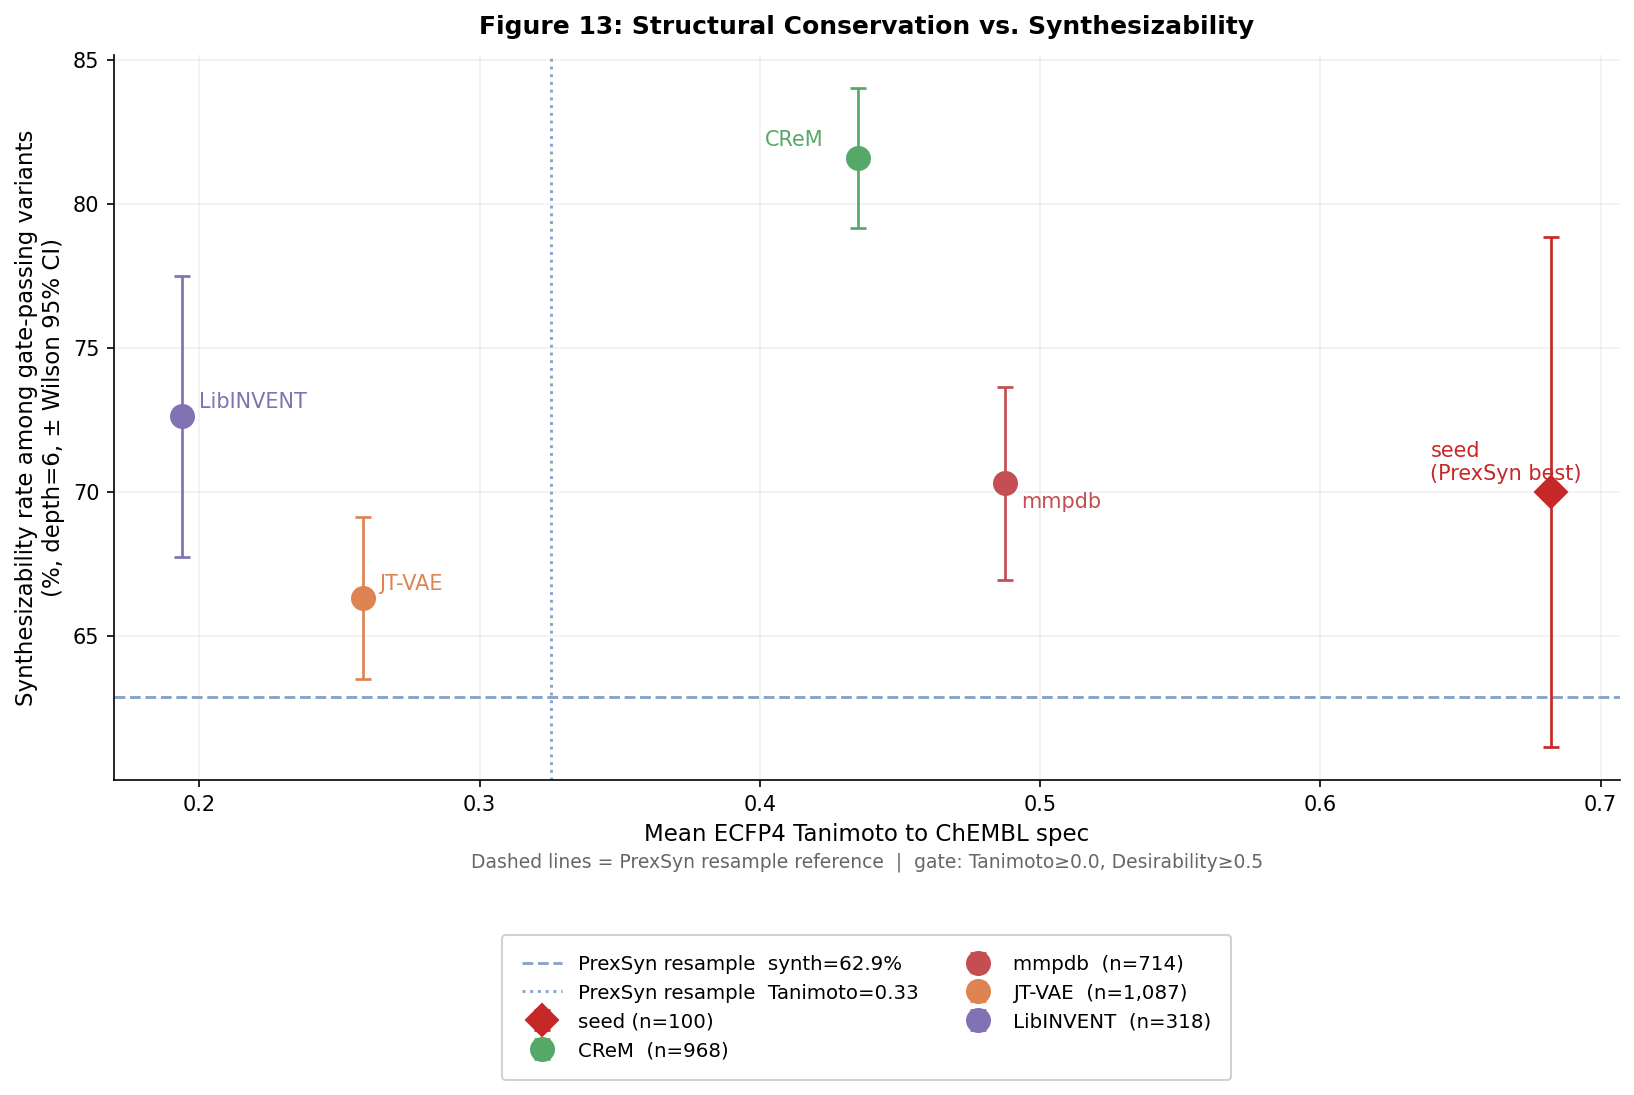

Saved -> D:\AI4DD Project\CSC2541-Project\data\generation_stratified\fig13_tanimoto_vs_synth_rate.png

Seed: Tanimoto=0.682  synth_rate=70.0%  n=100
  Baseline    : Tanimoto=0.325  synth_rate=62.9%  n_gate=299
  CReM        : Tanimoto=0.435  synth_rate=81.6%  n_gate=968
  mmpdb       : Tanimoto=0.487  synth_rate=70.3%  n_gate=714
  JT-VAE      : Tanimoto=0.258  synth_rate=66.3%  n_gate=1,087
  LibINVENT   : Tanimoto=0.194  synth_rate=72.6%  n_gate=318


In [ ]:
# -- Figure 13: Tanimoto vs Synthesizability Rate (per-method summary scatter) --
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def wilson_ci(k, n, z=1.96):
    if n == 0:
        return 0.0
    p = k / n
    denom = 1 + z**2 / n
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return half

# ── Seed reference ────────────────────────────────────────────────────────────
_seed_synth = pd.read_csv(GEN_DIR / 'seed_synth_results.csv')
_col = f'seed_is_synth_depth{VIZ_DEPTH}' if f'seed_is_synth_depth{VIZ_DEPTH}' in _seed_synth.columns else 'seed_is_synth_depth6'
seed_tan_mean   = _seed_synth['baseline_quality'].mean()
seed_k          = _seed_synth[_col].fillna(False).sum()
seed_n          = len(_seed_synth)
seed_synth_rate = seed_k / seed_n
seed_synth_ci   = wilson_ci(seed_k, seed_n)

# ── Per-method stats (gate-passing only) ──────────────────────────────────────
MOD_METHODS = ['CReM', 'mmpdb', 'JT-VAE', 'LibINVENT']
points = {}
for name in VIZ_METHODS:
    df   = viz_dfs[name]
    col  = VIZ_COL if VIZ_COL in df.columns else 'is_synth'
    gate = (df['tanimoto'] >= TAU_T_VIZ) & (df['desirability'] >= TAU_D_VIZ)
    gate_df = df[gate]
    tan = df['tanimoto'].dropna()
    synth_flags = gate_df[col].fillna(False).astype(bool)
    k, n = synth_flags.sum(), len(gate_df)
    points[name] = {
        'tan_mean':   tan.mean(),
        'synth_rate': k / n if n > 0 else 0.0,
        'synth_ci':   wilson_ci(k, n),
        'n_gate':     n,
    }

baseline_p = points['Baseline']
SEED_COLOR = '#C62828'

# ── Annotation offsets (method -> (dx, dy) in points) ────────────────────────
ANNOT_OFFSET = {
    'CReM':      (-45, 6),
    'mmpdb':     (8,  -12),
    'JT-VAE':    (8,    4),
    'LibINVENT': (8,    4),
}

fig, ax = plt.subplots(figsize=(11, 7))

# Seed star
ax.errorbar(
    seed_tan_mean, seed_synth_rate * 100,
    yerr=seed_synth_ci * 100,
    fmt='D', color=SEED_COLOR, markersize=11,
    capsize=4, capthick=1.3, elinewidth=1.3,
    zorder=4, label=f'seed (n={seed_n})',
)
ax.annotate(
    f'seed',
    xy=(seed_tan_mean, seed_synth_rate * 100),
    xytext=(-58, 6), textcoords='offset points',
    fontsize=10, color=SEED_COLOR,
    arrowprops=dict(arrowstyle='-', color=SEED_COLOR, lw=0.8, alpha=0.6),
)

# PrexSyn resample reference lines
ax.axhline(
    baseline_p['synth_rate'] * 100,
    color=PALETTE['Baseline'], lw=1.4, ls='--', alpha=0.65,
    label=f"PrexSyn resample  synth={baseline_p['synth_rate']*100:.1f}%",
    zorder=1,
)
ax.axvline(
    baseline_p['tan_mean'],
    color=PALETTE['Baseline'], lw=1.4, ls=':', alpha=0.65,
    label=f"PrexSyn resample  Tanimoto={baseline_p['tan_mean']:.2f}",
    zorder=1,
)

# Modification methods
for name in MOD_METHODS:
    p = points[name]
    ax.errorbar(
        p['tan_mean'], p['synth_rate'] * 100,
        yerr=p['synth_ci'] * 100,
        fmt='o', color=PALETTE[name], markersize=11,
        capsize=4, capthick=1.3, elinewidth=1.3,
        label=f'{name}  (n={p["n_gate"]:,})',
        zorder=3,
    )
    dx, dy = ANNOT_OFFSET.get(name, (8, 4))
    ax.annotate(
        name,
        xy=(p['tan_mean'], p['synth_rate'] * 100),
        xytext=(dx, dy), textcoords='offset points',
        fontsize=10, color=PALETTE[name],
    )

ax.set_xlabel('Mean ECFP4 Tanimoto to ChEMBL spec', fontsize=11)
ax.set_ylabel(
    f'Synthesizability rate among gate-passing variants\n(%, depth={VIZ_DEPTH}, \u00b1 Wilson 95% CI)',
    fontsize=11,
)
ax.set_title(
    'Figure 13: Structural Conservation vs. Synthesizability',
    fontweight='bold', fontsize=12, pad=10,
)

# Legend below the plot
ax.legend(
    fontsize=9.5, frameon=True, framealpha=0.9,
    loc='upper center', bbox_to_anchor=(0.5, -0.20),
    ncol=2, borderpad=1.0,
)
ax.grid(True, alpha=0.18)

# Subtitle note
ax.text(
    0.5, -0.12,
    f'Dashed lines = PrexSyn resample reference  |  gate: Tanimoto\u2265{TAU_T_VIZ}, Desirability\u2265{TAU_D_VIZ}',
    transform=ax.transAxes, ha='center', fontsize=9, color='#666666',
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.25)
out_path = GEN_DIR / 'fig13_tanimoto_vs_synth_rate.png'
plt.savefig(out_path, bbox_inches='tight', dpi=200)
plt.show()
print(f'Saved -> {out_path}')
print(f'\nSeed: Tanimoto={seed_tan_mean:.3f}  synth_rate={seed_synth_rate*100:.1f}%  n={seed_n}')
for name in VIZ_METHODS:
    p = points[name]
    print(f"  {name:<12}: Tanimoto={p['tan_mean']:.3f}  synth_rate={p['synth_rate']*100:.1f}%  n_gate={p['n_gate']:,}")
